In [2]:
import pandas as pd
import numpy as np

# === 參數設定 ===
WINDOW_SIZE = 100
OVERLAP = 0.5
STRIDE = int(WINDOW_SIZE * (1 - OVERLAP))
TRAIN_RATIO = 0.75

# === 檔案路徑 ===
files = [
    "../data/raw/e0-bridge.csv",
    "../data/raw/e1-lake.csv",
    "../data/raw/e2-forest.csv",
    "../data/raw/e3-river.csv",
    "../data/raw/e4-garden.csv"
]

# === device mapping ===
device_to_label = {
    "RIOT-BLE-0": 0,
    "RIOT-BLE-1": 1,
    "RIOT-BLE-2": 2,
    "RIOT-BLE-3": 3
}

# === 儲存結果 ===
X_train, y_train = [], []
X_test, y_test = [], []

def create_windows(data, label, window_size, stride):
    X, y = [], []
    if len(data) < window_size:
        return X, y

    for i in range(0, len(data) - window_size + 1, stride):
        seq = data[i:i + window_size]
        X.append(seq)
        y.append(label)

    return X, y

# === 處理每個環境 ===
for env_id, file in enumerate(files):
    df = pd.read_csv(file)

    # 時間排序
    df["ts"] = pd.to_datetime(df["ts"])
    df = df.sort_values("ts")

    # 每個 node 分開處理
    for device, label in device_to_label.items():
        df_node = df[df["device"] == device].copy()
        if len(df_node) < WINDOW_SIZE + 1:
            continue

        # 差分
        df_node["rssi_diff"] = df_node["rssi"].diff()
        df_node = df_node.dropna(subset=["rssi_diff"]).reset_index(drop=True)

        if len(df_node) < WINDOW_SIZE:
            continue

        # === 先按時間切分 75/25 ===
        split_idx = int(len(df_node) * TRAIN_RATIO)

        train_df = df_node.iloc[:split_idx].copy()
        test_df = df_node.iloc[split_idx:].copy()

        # test 至少要夠切一個窗
        if len(train_df) < WINDOW_SIZE or len(test_df) < WINDOW_SIZE:
            continue

        # === normalization ===
        train_min = df_node["rssi_diff"].min()
        train_max = df_node["rssi_diff"].max()

        if train_max - train_min == 0:
            continue
        
        train_df["rssi_diff_norm"] = (train_df["rssi_diff"] - train_min) / (train_max - train_min)
        test_df["rssi_diff_norm"] = (test_df["rssi_diff"] - train_min) / (train_max - train_min)

        train_data = train_df["rssi_diff_norm"].values
        test_data = test_df["rssi_diff_norm"].values

        # === 各自切窗 ===
        X_tr, y_tr = create_windows(train_data, label, WINDOW_SIZE, STRIDE)
        X_te, y_te = create_windows(test_data, label, WINDOW_SIZE, STRIDE)

        X_train.extend(X_tr)
        y_train.extend(y_tr)
        X_test.extend(X_te)
        y_test.extend(y_te)

# === 轉 numpy ===
X_train = np.array(X_train, dtype=np.float32)
y_train = np.array(y_train, dtype=np.int64)
X_test = np.array(X_test, dtype=np.float32)
y_test = np.array(y_test, dtype=np.int64)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4443, 100)
y_train shape: (4443,)
X_test shape: (1461, 100)
y_test shape: (1461,)


In [3]:
# =========================
# Step 1: tensor + dataloader
# =========================
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)
y_train = y_train.astype(np.int64)
y_test = y_test.astype(np.int64)
# CNN expects input shape: (batch_size, channels, sequence_length)
X_train = X_train[:, np.newaxis, :]
X_test = X_test[:, np.newaxis, :]

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor  = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("X_train:", X_train_tensor.shape)
print("X_test :", X_test_tensor.shape)
print("y_train:", y_train_tensor.shape)
print("y_test :", y_test_tensor.shape)

X_train: torch.Size([4443, 1, 100])
X_test : torch.Size([1461, 1, 100])
y_train: torch.Size([4443])
y_test : torch.Size([1461])


In [4]:
# =========================
# Step 2: define 1D CNN model (BN + GAP)
# =========================
import torch.nn as nn

class CNN1D(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),   # 100 -> 50
            nn.Dropout(0.1),

            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),   # 50 -> 25
            nn.Dropout(0.1),

            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


num_classes = len(np.unique(y_train))
model = CNN1D(num_classes=num_classes)
print(model)

CNN1D(
  (features): Sequential(
    (0): Conv1d(1, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.1, inplace=False)
    (5): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout(p=0.1, inplace=False)
    (10): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (11): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
 

In [5]:
# =========================
# Step 3: training setup
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

In [6]:
# =========================
# Step 4: training loop
# =========================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)

            outputs = model(xb)
            loss = criterion(outputs, yb)

            total_loss += loss.item() * xb.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

    return total_loss / total, correct / total

In [7]:
# =========================
# Step 5: run training (early stopping + best model)
# =========================
num_epochs = 50

train_losses = []
test_losses = []
train_accs = []
test_accs = []

best_state = None
best_test_loss = float("inf")
patience = 30
counter = 0

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    scheduler.step(test_loss)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    current_lr = optimizer.param_groups[0]["lr"]
    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"LR: {current_lr:.6f} | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}"
    )

    if test_loss < best_test_loss:
        best_test_loss = test_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

if best_state is not None:
    model.load_state_dict(best_state)

final_loss, final_acc = evaluate(model, test_loader, criterion, device)
print(f"\nBest-val model -> Test Loss: {final_loss:.4f}, Test Acc: {final_acc:.4f}")

Epoch [1/50] LR: 0.001000 | Train Loss: 1.1970, Train Acc: 0.4234 | Test Loss: 1.1713, Test Acc: 0.4559
Epoch [2/50] LR: 0.001000 | Train Loss: 1.0490, Train Acc: 0.5397 | Test Loss: 1.0911, Test Acc: 0.5346
Epoch [3/50] LR: 0.001000 | Train Loss: 0.9726, Train Acc: 0.6036 | Test Loss: 1.0288, Test Acc: 0.5804
Epoch [4/50] LR: 0.001000 | Train Loss: 0.9053, Train Acc: 0.6520 | Test Loss: 0.9655, Test Acc: 0.6427
Epoch [5/50] LR: 0.001000 | Train Loss: 0.8575, Train Acc: 0.6775 | Test Loss: 1.0101, Test Acc: 0.5845
Epoch [6/50] LR: 0.001000 | Train Loss: 0.8593, Train Acc: 0.6793 | Test Loss: 1.0063, Test Acc: 0.5859
Epoch [7/50] LR: 0.001000 | Train Loss: 0.8109, Train Acc: 0.7061 | Test Loss: 1.0281, Test Acc: 0.6188
Epoch [8/50] LR: 0.001000 | Train Loss: 0.8433, Train Acc: 0.6921 | Test Loss: 0.9349, Test Acc: 0.6619
Epoch [9/50] LR: 0.001000 | Train Loss: 0.8029, Train Acc: 0.7193 | Test Loss: 0.9347, Test Acc: 0.6708
Epoch [10/50] LR: 0.001000 | Train Loss: 0.7853, Train Acc: 0.71

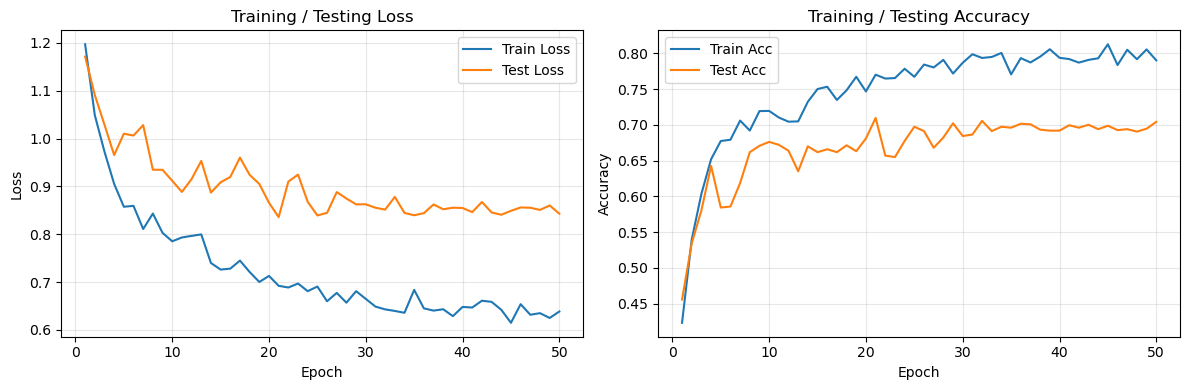

In [8]:
# =========================
# Step 5.5: plot training curves
# =========================
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training / Testing Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs, label='Train Acc')
plt.plot(epochs, test_accs, label='Test Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training / Testing Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# =========================
# Step 6: prediction example
# =========================
model.eval()

with torch.no_grad():
    sample_x = X_test_tensor[:10].to(device)
    outputs = model(sample_x)
    preds = outputs.argmax(dim=1).cpu().numpy()

print("Pred:", preds)
print("True:", y_test[:10])

Pred: [0 0 0 0 0 0 0 0 0 0]
True: [0 0 0 0 0 0 0 0 0 0]


In [10]:
# =========================
# Step 6.5: most predicted class on test set
# =========================
model.eval()
y_pred = []

with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        outputs = model(xb)
        pred = outputs.argmax(dim=1).cpu().numpy()
        y_pred.extend(pred)

y_pred = np.array(y_pred)
unique, counts = np.unique(y_pred, return_counts=True)
class_counts = dict(zip(unique, counts))

majority_class = int(unique[np.argmax(counts)])
majority_count = int(np.max(counts))
majority_ratio = majority_count / len(y_pred)

print("Pred class counts:", class_counts)
print(f"Most predicted class: {majority_class}")
print(f"Count / Ratio: {majority_count} / {majority_ratio:.2%}")

Pred class counts: {np.int64(0): np.int64(470), np.int64(1): np.int64(323), np.int64(2): np.int64(225), np.int64(3): np.int64(443)}
Most predicted class: 0
Count / Ratio: 470 / 32.17%


In [11]:
# =========================
# Step 7: confusion matrix
# =========================
from sklearn.metrics import confusion_matrix, classification_report

model.eval()
all_preds = []
all_true = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        outputs = model(xb)
        preds = outputs.argmax(dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_true.extend(yb.numpy())

cm = confusion_matrix(all_true, all_preds)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(all_true, all_preds))

Confusion Matrix:
 [[347  30  16  29]
 [ 93 207  17  41]
 [  8  70 179  69]
 [ 22  16  13 304]]

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.82      0.78       422
           1       0.64      0.58      0.61       358
           2       0.80      0.55      0.65       326
           3       0.69      0.86      0.76       355

    accuracy                           0.71      1461
   macro avg       0.72      0.70      0.70      1461
weighted avg       0.71      0.71      0.70      1461

